In [1]:
%%bash
mkdir storm_mode
cd storm_mode
wget -nc -q https://raw.githubusercontent.com/ahaberlie/unidata-workshop-2018/refs/heads/master/workshop/data/training/sample_train_data.csv
wget -nc -q https://raw.githubusercontent.com/ahaberlie/unidata-workshop-2018/refs/heads/master/workshop/data/training/sample_test_data.csv

# L6 - Scikit-Learn - Clustering

Directions:

1. Please rename the file by clicking on “LX-First-Last.ipynb” where X is the lab number, and replace First and Last with your first and last name.

2. Click File -> Save to make sure your most recent edits are saved.

3. In the upper right hand corner of the screen, click on “Share”. Click on “Restricted” and change it to “Anyone with the link”. Make sure you also share it with `ahaberlie1@gmail.com`.

4. Copy the link and submit it on Blackboard. Make sure you follow these steps completely, or I will be unable to grade your work.

### Overview

This lab will help you understand scikit-learn and its clustering capabilities. We will walk through some examples of how scikit-learn can help solve Geoscience problems. Periodically, I will 1) ask you to either repeat the demonstrated code in a slightly different way; or 2) ask you to combine two or more techniques to solve a problem.

You can use generative AI to help answer these problems. **The answer should still be in your own words.** Think of the generative AI descriptions as those from a book. You still have to cite your source and you cannot plagiarize directly from the source. For every question that you used generative AI for help, please reference the generative AI you used and what your prompt or prompts were.

However, it is crucial that you understand the code well enough to effectively use generative AI tools that are likely to be widely available and recommended for use at many organizations. Although they are improving at an incredible rate, they still produce bugs, especially with domain-specific and complex problems. Make sure that you verify the answers before putting them in your own words.

**Model performance assessment**

When assessing model performance, we typically separate the sample data into three subsets. Think of your own experiences preparing for an exam as motivation for the subsets:

1. Training data - this is what the machine learning approach uses to generate a model. Similar to lectures/homework/assignments/etc. in class.
2. Validation data - this is what is used to do quick "spot checks" on the model and help determine optimal model settings. This is similar to doing a practice quiz and learning what you need to focus on before the exam.
3. Testing data - this is what is used to test the performance of the model. This is similar to finally taking the exam.

I have provided you with the training and testing datasets. We will also generate the validation dataset below:

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

df_train = pd.read_csv("storm_mode/sample_train_data.csv")
df_test = pd.read_csv("storm_mode/sample_test_data.csv")
df_train, df_val = train_test_split(df_train, test_size=0.1, train_size=0.9)

print("# training samples (lectures/homework/etc.) =", len(df_train))
print("# validation samples (practice exam) =", len(df_val))
print("# validation samples (actual exam) =", len(df_test))

# training samples (lectures/homework/etc.) = 359
# validation samples (practice exam) = 40
# validation samples (actual exam) = 100


We can ask the `KMeans` model to predict the cluster for each sample.

Set `var1` and `var2` based on your exploration in [Chapter 8.2](https://ahaberlie.github.io/python_programming_geosciences/clustering/).

This code creates a new column named `kmeans_label` that has the cluster identifier (an `int` between 0 and 4).

In [3]:
import numpy as np
from sklearn.cluster import KMeans

var1 = 'mean_intensity'
var2 = 'solidity'

num_cluster = 5
seed = 0
n_init = 10

df_train_x = df_train[[var1, var2]].to_numpy(dtype=np.float64)
df_test_x = df_test[[var1, var2]].to_numpy(dtype=np.float64)

kmeans = KMeans(n_clusters=num_cluster, n_init=n_init, random_state=seed).fit(df_train_x)

# the KMeans trained instance predicts the cluster
preds = kmeans.predict(df_test_x)

# this is in order, so you can make a new column
df_test['kmeans_label'] = preds

df_test[['label_name', 'kmeans_label']]

,label_name,kmeans_label
0,MCS,4
1,MCS,2
2,MCS,0
3,MCS,0
4,MCS,4
...,...,...
95,Clutter,3
96,Clutter,3
97,Clutter,3
98,Clutter,3


Here is a direct comparison between the given labels (`label_name`) and the clustered labels (`kmeans_label`).

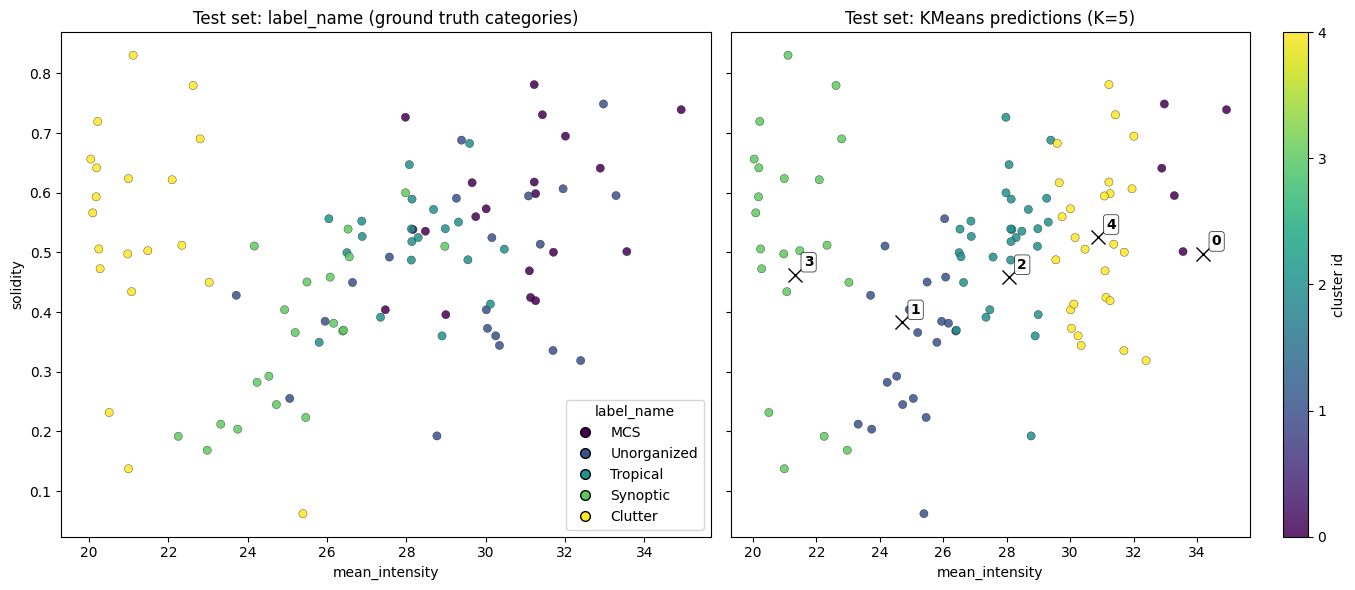

In [4]:
import numpy as np
import matplotlib.pyplot as plt

centers = kmeans.cluster_centers_

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

name_codes, name_levels = pd.factorize(df_test["label_name"])

sc0 = axes[0].scatter(
    df_test[var1], df_test[var2],
    c=name_codes,
    s=35, alpha=0.85,
    edgecolors="k", linewidths=0.25
)
axes[0].set_title("Test set: label_name (ground truth categories)")
axes[0].set_xlabel(var1)
axes[0].set_ylabel(var2)

handles0 = []
for code, name in enumerate(name_levels):
    handles0.append(
        plt.Line2D(
            [0], [0],
            marker="o", linestyle="",
            markerfacecolor=sc0.cmap(sc0.norm(code)),
            markeredgecolor="k",
            markersize=7,
            label=str(name),
        )
    )
if len(handles0) <= 15:
    axes[0].legend(handles=handles0, title="label_name", loc="best")

sc1 = axes[1].scatter(
    df_test[var1], df_test[var2],
    c=preds,
    s=35, alpha=0.85,
    edgecolors="k", linewidths=0.25
)

axes[1].plot(centers[:, 0], centers[:, 1], "kx", markersize=10)

for k, (cx, cy) in enumerate(centers):
    axes[1].annotate(
        str(k),
        (cx, cy),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="k", lw=0.5, alpha=0.9),
    )

axes[1].set_title(f"Test set: KMeans predictions (K={num_cluster})")
axes[1].set_xlabel(var1)

cbar = fig.colorbar(sc1, ax=axes[1], ticks=np.arange(num_cluster))
cbar.set_label("cluster id")

plt.tight_layout()
plt.show()

### Problem 1

This approach is similar to a [search engine](https://en.wikipedia.org/wiki/Search_engine). One of the ways to assess a search engine is to look at how many relevant results are returned using metrics like [precision and recall](https://en.wikipedia.org/wiki/Precision_and_recall).

We first need to define the terms used in these metrics:

1. `True Positive` or `TP` - Count of how many relevant result are found (e.g., acceptable google search result)
2. `False Positive` or `FP` - Count of how many non-relevant results are found (e.g., an unacceptable google search result)
3. `False Negative` or `FN` - Count of how many relevant results are not found (e.g., your google search missed a good result)

There is also a `True Negative` or `TN`, but it is not relevant for this particular problem. A search engine is focused on "postives".

We will be calculating:

1. `precision` - what percent of the found results are relevant?
> `prec = TP / (TP + FP)`
2. `recall` - what percent of the relevant results are found?
> `rec = TP / (TP + FN)`

They might sound the same, but the answer different questions about the quality of the clustering algorithm. Our lab exploration will examine these in detail below and have you reflect on the differences. Can you think of a way to differentiate these metrics in meteorology? What would `precision` and/or `recall` tell you about the performance / quality of a forecast?

**Connecting `KMeans` to the expert labels**

The code below groups the testing data by `kmeans_label` and creates a pie chart of how many of each `label_name` belong to each `kmeans_label` group.

Based on this analysis, assign one of the 5 possible `label_names` to the following `KMeans` labels. For example, if you think Label 0 describes 'MCS' the best, replace:

- `KMeans Label 0 - [Your Class]`
with
- `KMeans Label 0 - MCS`
Class


*Each blank is worth 0.25 points. It must be in your own words (NO AI)*

### Problem 1a (2 pts)

`KMeans` Label 0 is best associated with [label_name]

> TP =

> FP =

> FN =

> prec =

> rec =

> Why did you choose [label_name]?

> How would you communicate to someone else how well this cluster performs for the chosen [label_name]?

### Problem 1b (2 pts)

`KMeans` Label 1 is best associated with [label_name]

> TP =

> FP =

> FN =

> prec =

> rec =

> Why did you choose [label_name]?

> How would you communicate to someone else how well this cluster performs for the chosen [label_name]?

### Problem 1c (2 pts)

`KMeans` Label 2 is best associated with [label_name]

> TP =

> FP =

> FN =

> prec =

> rec =

> Why did you choose [label_name]?

> How would you communicate to someone else how well this cluster performs for the chosen [label_name]?

### Problem 1d (2 pts)

`KMeans` Label 3 is best associated with [label_name]

> TP =

> FP =

> FN =

> prec =

> rec =

> Why did you choose [label_name]?

> How would you communicate to someone else how well this cluster performs for the chosen [label_name]?

### Problem 1e (2 pts)

`KMeans` Label 4 is best associated with [label_name]

> TP =

> FP =

> FN =

> prec =

> rec =

> Why did you choose [label_name]?

> How would you communicate to someone else how well this cluster performs for the chosen [label_name]?

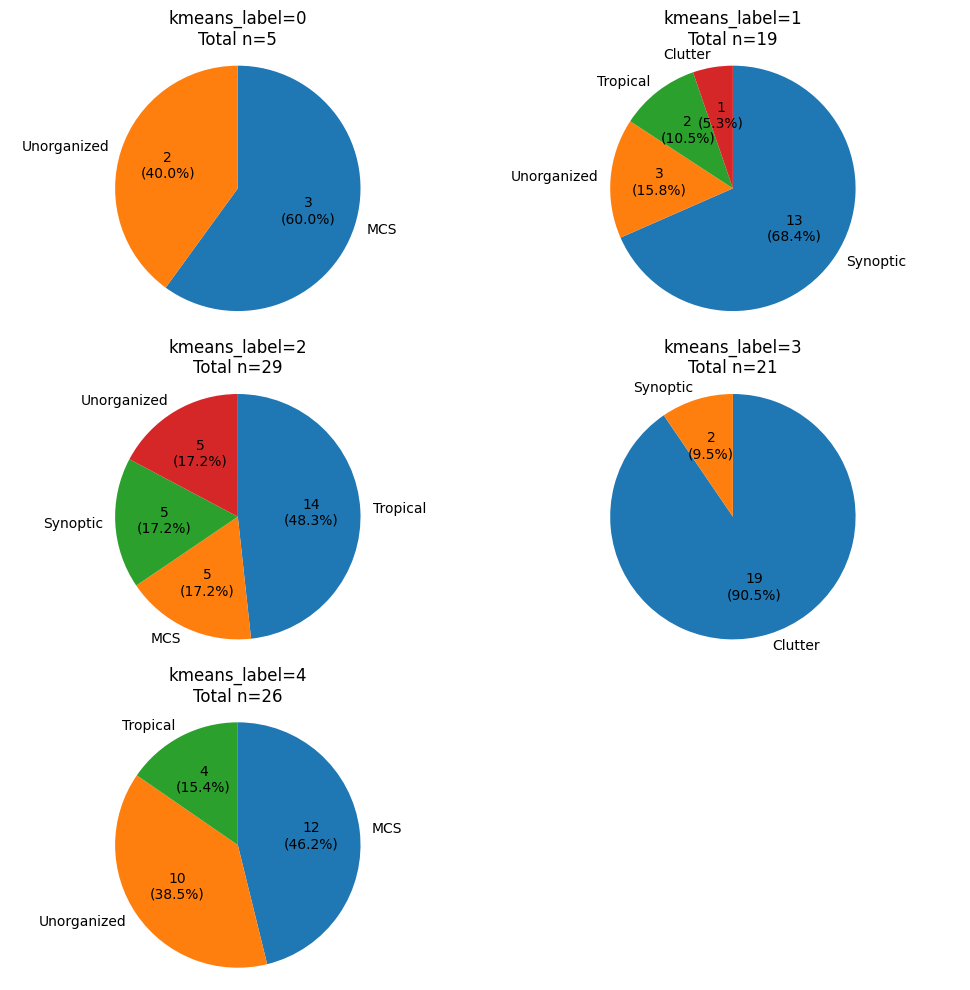

In [5]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 10)

def autopct_fmt(pct):
    count = int(round(pct * total / 100.0))
    return f"{count}\n({pct:.1f}%)"

for km_label in [0, 1, 2, 3, 4]:
    ax = plt.subplot(3, 2, km_label + 1)

    subset = df_test[df_test["kmeans_label"] == km_label]
    counts = subset.groupby("label_name").size().sort_values(ascending=False)

    total = int(counts.sum())

    counts.plot(
        kind="pie",
        ax=ax,
        autopct=autopct_fmt,
        startangle=90,
        counterclock=False,
        ylabel="",
    )

    ax.set_title(f"kmeans_label={km_label}\nTotal n={total}")

    ax.axis("equal")

plt.tight_layout()